# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset pertence ao domínio de negócios em telecomunicações e foi coletado aleatoriamente a partir de uma base de uma empresa iraniana da área ao longo de 12 meses. O objetivo do dataset é apoiar tarefas de classificação binária, como previsão de evasão de clientes. A base contem 3150 instâncias, cada uma representando um cliente, com 13 atributos preditores e sem valores ausentes, incluindo informações de falhas de chamadas, reclamações, tempo de assinatura, valor de recarga, segundos de uso, frequência de chamadas, frequência de SMS, quantidade de números distintos chamados, grupo de idade, plano tarifário, status do cliente e valor calculado do cliente.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
print("Dimensões do dataframe:", df.shape)

TARGET_COLUMN = ds.data.targets.columns[0]

print("Variável alvo:", TARGET_COLUMN)
print("Valores únicos da variável alvo:", df[TARGET_COLUMN].unique())

Dimensões do dataframe: (3150, 14)
Variável alvo: Churn
Valores únicos da variável alvo: [0 1]


In [6]:
TARGET_COLUMN = "Churn"

O dataframe possui 3150 amostras e 14 colunas no total, sendo 13 atributos preditores e 1 variável alvo. A variável alvo é Churn. O problema é de classificação binária, pois Churn possui apenas dois valores únicos: 0 e 1

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [7]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_props = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Quantidade": target_counts,
    "Proporção (%)": target_props.round(2)
}))

,Quantidade,Proporção (%)
Churn,,
0,2655,84.29
1,495,15.71


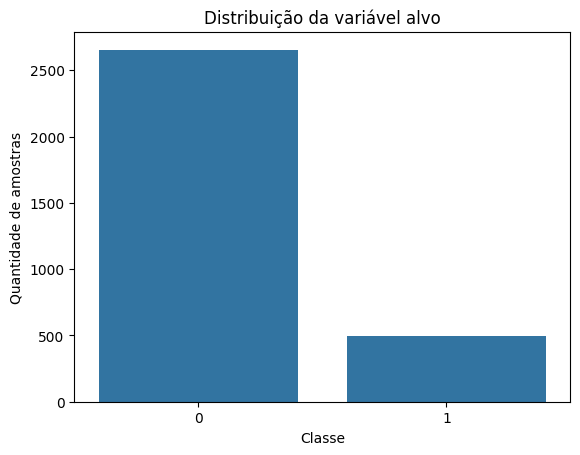

In [8]:
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade de amostras")
plt.show()

O dataset é desbalanceado, pois a classe 0 possui 2655 amostras, 84,29% do total, enquanto a classe 1 possui apenas 495 amostras, 15,71%. Portanto, há predominância da classe 0.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

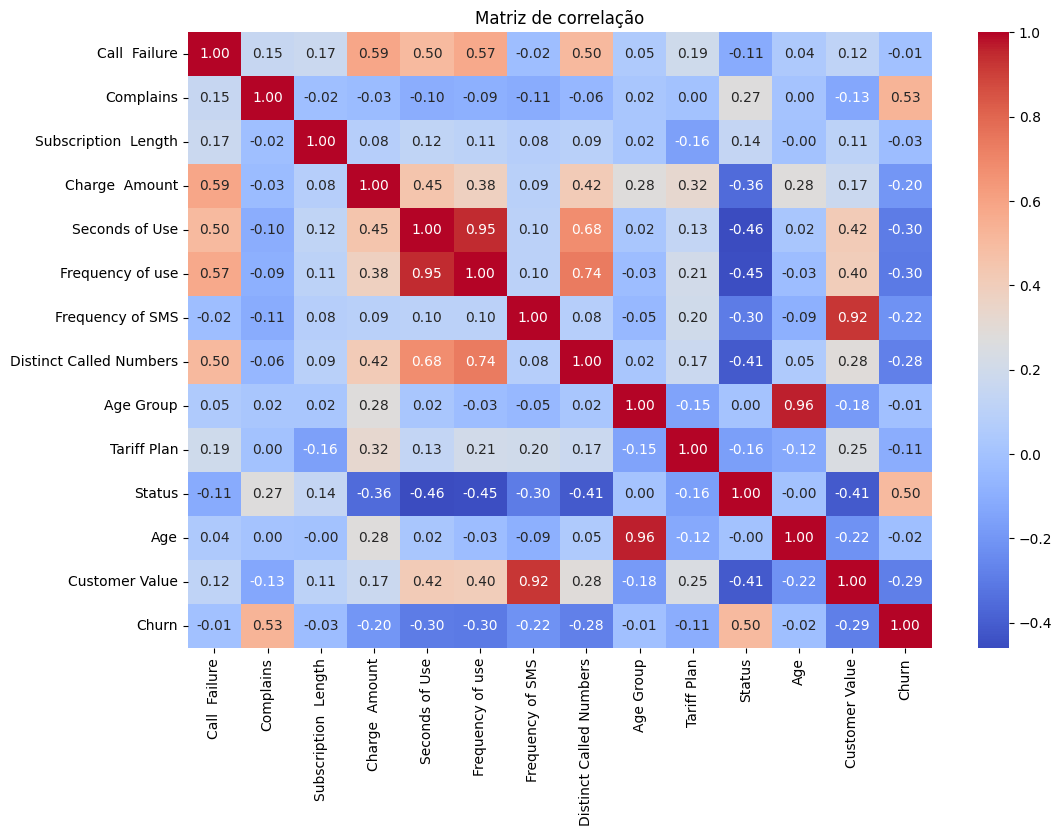

In [9]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

In [10]:
target_corr = corr_matrix[[TARGET_COLUMN]].sort_values(
    by=TARGET_COLUMN,
    ascending=False
)

display(target_corr)

,Churn
Churn,1.000000
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705
Subscription Length,-0.032588
Tariff Plan,-0.105853
Charge Amount,-0.202305
Frequency of SMS,-0.220754


Os atributos com maior correlação positiva com Churn são Complains (0.53) e Status (0.50), indicando maior associação com a evasão. As maiores correlações negativas são Frequency of use (-0.30), Seconds of Use (-0.30), Customer Value (-0.29) e Distinct Called Numbers (-0.28). Assim, esses atributos podem ser mais relevantes para o problema de classificação.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

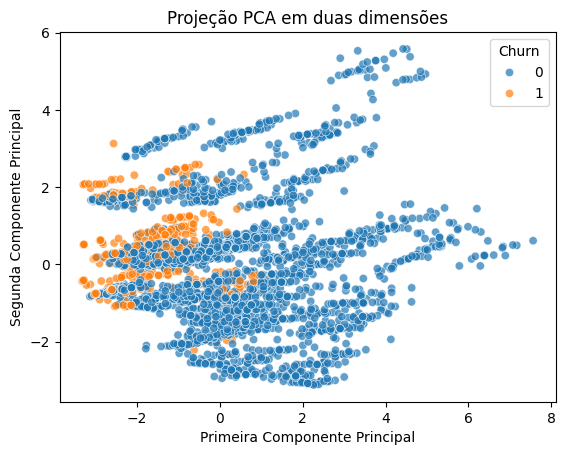

Variância explicada: [0.30904449 0.17841786]
Variância explicada acumulada: 0.4874623541704386


In [11]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[TARGET_COLUMN] = y.values

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COLUMN, alpha=0.7)
plt.title("Projeção PCA em duas dimensões")
plt.xlabel("Primeira Componente Principal")
plt.ylabel("Segunda Componente Principal")
plt.show()

print("Variância explicada:", pca.explained_variance_ratio_)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.sum())

Pela projeção em duas dimensões, não há separação clara entre as classes. Os pontos das classes 0 e 1 aparecem com sobreposição significativa, indicando que as duas primeiras componentes principais não isolam bem os clientes churn e não churn.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [12]:
features = df.columns.drop(TARGET_COLUMN)

X = df[features]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A padronização é importante porque coloca os atributos em uma escala comparável, com média zero e desvio padrão unitário, evitando que variáveis com valores maiores dominem o treinamento do modelo. O fit deve ser aplicado apenas no conjunto de treino porque ele calcula média e desvio padrão; se fosse ajustado usando também o teste, haveria vazamento de informação do teste para o treinamento.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [13]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Número de iterações:", model.n_iter_[0])
print("Convergiu:", model.n_iter_[0] < model.max_iter)

Número de iterações: 42
Convergiu: True


A regressão logística atua como um classificador binário para prever se um cliente pertence à classe 0 ou 1. O modelo aprende, a partir dos dados de treino, os pesos associados a cada atributo para estimar a probabilidade de uma amostra pertencer à classe positiva. O treinamento busca ajustar esses pesos minimizando o erro de classificação por meio de uma função de perda.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [14]:
y_proba = model.predict_proba(X_test_scaled)

proba_df = pd.DataFrame(
    y_proba,
    columns=[f"P({TARGET_COLUMN}={classe})" for classe in model.classes_]
)

proba_df["Classe prevista"] = model.predict(X_test_scaled)
proba_df["Confiança"] = y_proba.max(axis=1)

display(proba_df.head(10))

,P(Churn=0),P(Churn=1),Classe prevista,Confiança
0,0.998819,0.001181,0,0.998819
1,0.999954,0.000046,0,0.999954
2,0.974259,0.025741,0,0.974259
3,0.999518,0.000482,0,0.999518
4,0.998645,0.001355,0,0.998645
5,0.997155,0.002845,0,0.997155
6,0.991459,0.008541,0,0.991459
7,0.991455,0.008545,0,0.991455
8,0.987025,0.012975,0,0.987025
9,0.590190,0.409810,0,0.590190


Cada linha representa uma amostra do conjunto de teste. A coluna P(Churn=0) indica a probabilidade estimada de o cliente não cancelar, enquanto P(Churn=1) indica a probabilidade estimada de churn. A classe prevista é aquela com maior probabilidade. Valores próximos de 1 indicam alta confiança; valores próximos de 0,5 indicam maior incerteza

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [15]:
positive_idx = np.where(model.classes_ == 1)[0][0]
y_score = y_proba[:, positive_idx]

results = []

for threshold in [0.5, 0.7]:
    y_pred_thr = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()

    results.append({
        "Limiar": threshold,
        "Previstos como 0": (y_pred_thr == 0).sum(),
        "Previstos como 1": (y_pred_thr == 1).sum(),
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp
    })

threshold_results = pd.DataFrame(results)
display(threshold_results)

,Limiar,Previstos como 0,Previstos como 1,VN,FP,FN,VP
0,0.5,570,60,504,16,66,44
1,0.7,588,42,514,6,74,36


Ao aumentar o limiar de 0.5 para 0.7, o modelo fica mais exigente para classificar um cliente como Churn = 1. Assim, a tendência é reduzir a quantidade de previsões positivas, diminuindo os falsos positivos, mas aumentando os falsos negativos, pois alguns clientes que realmente deram churn podem deixar de ser identificados. Portanto, o limiar 0.5 é mais permissivo, enquanto o limiar 0.7 prioriza maior confiança para prever a classe positiva.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

,Limiar,Acurácia,Precisão,Recall,F1-score
0,0.5,0.869841,0.733333,0.400000,0.517647
1,0.7,0.873016,0.857143,0.327273,0.473684


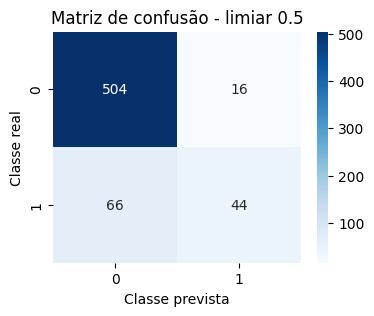

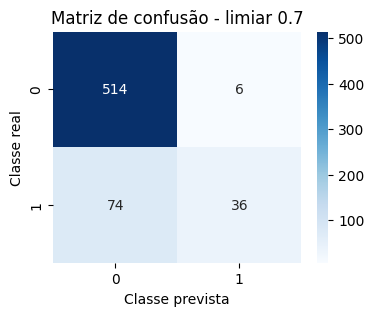

In [16]:
def avaliar_limiar(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    return {
        "Limiar": threshold,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

metricas = pd.DataFrame([
    avaliar_limiar(y_test, y_score, 0.5),
    avaliar_limiar(y_test, y_score, 0.7)
])

display(metricas)

for threshold in [0.5, 0.7]:
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusão - limiar {threshold}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

Ao aumentar o limiar de 0.5 para 0.7, o modelo passa a prever menos casos como Churn = 1. Com isso, a precisão tende a aumentar, pois as previsões positivas restantes são mais confiáveis, enquanto o recall tende a diminuir, pois mais clientes que realmente deram churn deixam de ser identificados. Assim, a métrica mais impactada pela mudança do limiar costuma ser o recall.

O trade-off observado é: limiar menor detecta mais churns, mas gera mais falsos positivos; limiar maior reduz falsos positivos, mas aumenta falsos negativos.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O dataset pertence ao domínio da biologia/ecolofia e tem como objetivo prever o tipo de cobertura florestal de uma área a partir de variáveis cartográficas. A base contem 581.012 amostras e 54 atributos, incluindo informaçoes como elevação, aspecto, inclinação, sombreamento, distância atérecursos hidrológicos, estradas e áreas de incêndio, além de variaveis relacionadas a areas de preservação e tipos de solo.

In [17]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [18]:
TARGET_COLUMN = ds.data.targets.columns[0]

display(df.head())
print("Dimensões:", df.shape)
print("Variável alvo:", TARGET_COLUMN)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


Dimensões: (58101, 55)
Variável alvo: Cover_Type


In [19]:
print("Valores únicos da variável alvo:")
print(sorted(df[TARGET_COLUMN].unique()))

print("Quantidade de classes:", df[TARGET_COLUMN].nunique())
print(df[TARGET_COLUMN].value_counts().sort_index())

Valores únicos da variável alvo:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Quantidade de classes: 7
Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


In [20]:
TARGET_COLUMN = "Cover_Type"

O dataframe amostrado possui 58.101 amostras e 55 colunas, sendo 54 atributos preditores e 1 variável alvo. A variável alvo é Cover_Type. O problema não é de classificação binária, pois a variável alvo possui 7 valores únicos. Portanto, trata-se de um problema de classificação multiclasse.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [21]:
target_distribution = df[TARGET_COLUMN].value_counts().sort_index()
target_percentage = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Quantidade": target_distribution,
    "Proporção (%)": target_percentage.round(2)
}))

,Quantidade,Proporção (%)
Cover_Type,,
1,21297,36.66
2,28248,48.62
3,3607,6.21
4,259,0.45
5,932,1.60
6,1706,2.94
7,2052,3.53


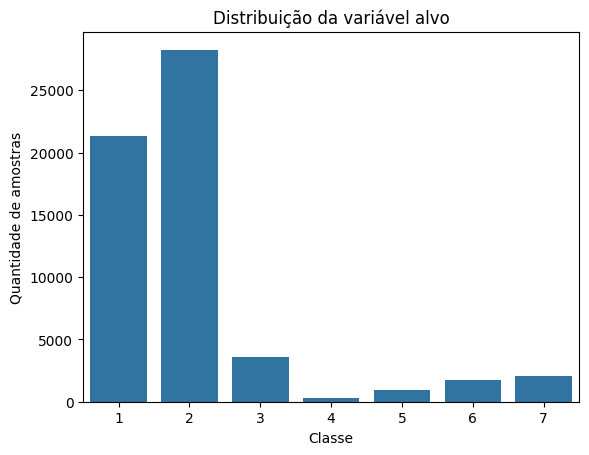

In [22]:
sns.countplot(data=df, x=TARGET_COLUMN)

plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade de amostras")
plt.show()

O dataset é desbalanceado, pois as classes não possuem quantidades semelhantes de amostras. Pela distribuição, as classes 1 e 2 concentram a maior parte dos dados, enquanto as classes 3, 4, 5, 6 e 7 aparecem com bem menos amostras.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

In [23]:
corr_target = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)

corr_df = pd.DataFrame({
    "Correlação": corr_target,
    "|Correlação|": corr_target.abs()
}).sort_values("|Correlação|", ascending=False)

display(corr_df)
display(corr_df[corr_df["|Correlação|"] >= 0.2])

,Correlação,|Correlação|
Wilderness_Area4,0.317518,0.317518
Elevation,-0.268264,0.268264
Soil_Type10,0.236392,0.236392
Wilderness_Area1,-0.200715,0.200715
Soil_Type39,0.163504,0.163504
Soil_Type38,0.162663,0.162663
Horizontal_Distance_To_Roadways,-0.155258,0.155258
Slope,0.145731,0.145731
Soil_Type22,-0.140253,0.140253
Soil_Type23,-0.133668,0.133668


,Correlação,|Correlação|
Wilderness_Area4,0.317518,0.317518
Elevation,-0.268264,0.268264
Soil_Type10,0.236392,0.236392
Wilderness_Area1,-0.200715,0.200715


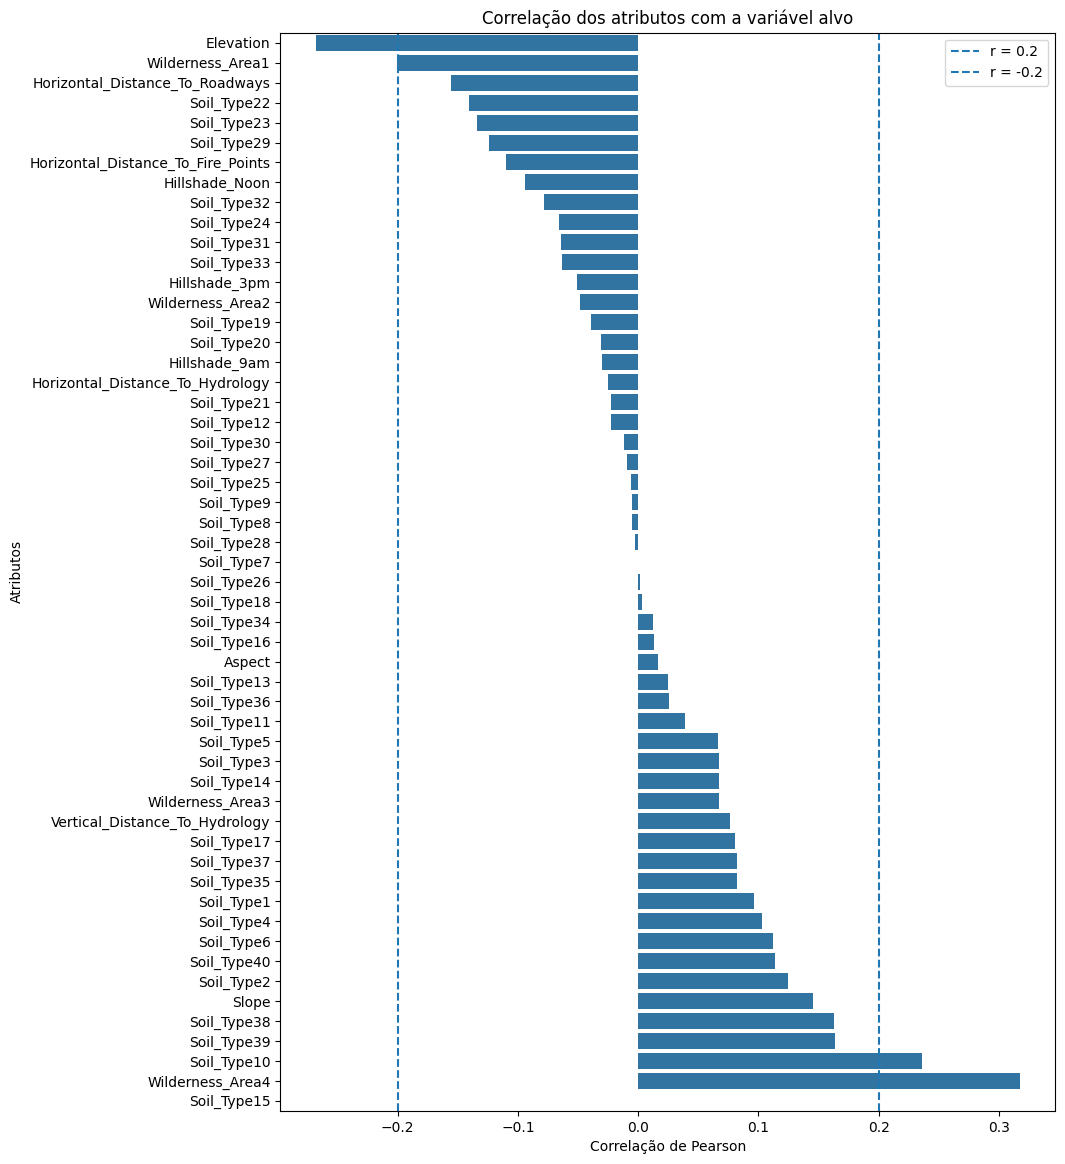

In [24]:
corr_plot = corr_target.sort_values()

plt.figure(figsize=(10, 14))
sns.barplot(x=corr_plot.values, y=corr_plot.index)

plt.axvline(0.2, linestyle="--", label="r = 0.2")
plt.axvline(-0.2, linestyle="--", label="r = -0.2")

plt.title("Correlação dos atributos com a variável alvo")
plt.xlabel("Correlação de Pearson")
plt.ylabel("Atributos")
plt.legend()
plt.show()

As variáveis mais relevantes são aquelas com maior correlação em valor absoluto com Cover_Type, especialmente as que ultrapassam as linhas de referência em |r| = 0.2. Esses atributos apresentam associação linear mais forte com a variável alvo e podem contribuir mais para o modelo.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

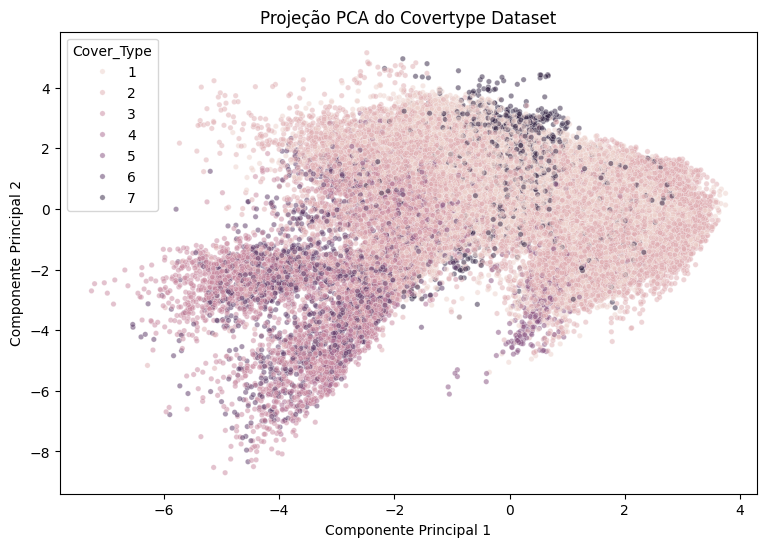

Variância explicada por componente: [0.06948199 0.05517254]
Variância explicada acumulada: 0.12465453211189659


In [25]:
entradas = df.drop(columns=TARGET_COLUMN)
saida = df[TARGET_COLUMN]

normalizador = StandardScaler()
entradas_norm = normalizador.fit_transform(entradas)

redutor_pca = PCA(n_components=2)
componentes = redutor_pca.fit_transform(entradas_norm)

df_componentes = pd.DataFrame(componentes, columns=["CP1", "CP2"])
df_componentes["Classe"] = saida.to_numpy()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_componentes,
    x="CP1",
    y="CP2",
    hue="Classe",
    alpha=0.5,
    s=15
)

plt.title("Projeção PCA do Covertype Dataset")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title=TARGET_COLUMN)
plt.show()

print("Variância explicada por componente:", redutor_pca.explained_variance_ratio_)
print("Variância explicada acumulada:", redutor_pca.explained_variance_ratio_.sum())

Pela projeção em duas dimensões, não há separação totalmente clara entre as classes. Algumas regiões podem concentrar mais amostras de determinadas classes, mas existe sobreposição significativa entre os grupos, indicando que as duas primeiras componentes principais não são suficientes para separar perfeitamente os 7 tipos de cobertura florestal.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [26]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)
print("Número de folds:", kf.get_n_splits())

Treino: (46480, 54)
Teste: (11621, 54)
Número de folds: 5


A validação cruzada k-fold é importante porque avalia o modelo em diferentes divisões dos dados, reduzindo a dependência de uma única separação treino/teste. Assim, obtém-se uma estimativa mais estável do desempenho e da capacidade de generalização do classificador

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [27]:
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr)
    X_val_scaled = fold_scaler.transform(X_val)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_scaled, y_tr)

    y_val_pred = clf.predict(X_val_scaled)

    n_iter = clf.n_iter_.max()
    convergiu = n_iter < clf.max_iter

    print(f"Fold {fold} - Iterações: {n_iter} - Convergiu: {convergiu}")

    fold_results.append({
        "Fold": fold,
        "Acurácia": accuracy_score(y_val, y_val_pred),
        "Precisão": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "Iterações": n_iter,
        "Convergiu": convergiu
    })

cv_results = pd.DataFrame(fold_results)

display(cv_results)

print("Média das métricas:")
display(cv_results[["Acurácia", "Precisão", "Recall", "F1-score"]].mean())

Fold 1 - Iterações: 184 - Convergiu: True
Fold 2 - Iterações: 179 - Convergiu: True
Fold 3 - Iterações: 217 - Convergiu: True
Fold 4 - Iterações: 205 - Convergiu: True
Fold 5 - Iterações: 180 - Convergiu: True


,Fold,Acurácia,Precisão,Recall,F1-score,Iterações,Convergiu
0,1,0.731497,0.716914,0.731497,0.722026,184,True
1,2,0.723967,0.707793,0.723967,0.712210,179,True
2,3,0.719664,0.713185,0.719664,0.709671,217,True
3,4,0.728055,0.710507,0.728055,0.717811,205,True
4,5,0.726549,0.714583,0.726549,0.716690,180,True


Média das métricas:


,0
Acurácia,0.725947
Precisão,0.712597
Recall,0.725947
F1-score,0.715682


A regressão logística multiclasse foi usada para prever a classe Cover_Type a partir dos atributos do dataset. Em cada fold, o modelo aprende pesos para associar os atributos de entrada às 7 classes possíveis. A padronização foi aplicada dentro de cada fold para evitar vazamento de dados. A média das métricas representa o desempenho geral do modelo nos 5 folds, e o n_iter_ indica se o treinamento convergiu corretamente.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [28]:
escala_final = StandardScaler()
X_treino_final = escala_final.fit_transform(X_train)
X_teste_final = escala_final.transform(X_test)

modelo_final = LogisticRegression(
    C=0.01,
    penalty="l2",
    max_iter=1000,
    random_state=42
)

modelo_final.fit(X_treino_final, y_train)

prob_teste = modelo_final.predict_proba(X_teste_final)

df_probabilidades = pd.DataFrame(
    prob_teste,
    columns=[f"P({TARGET_COLUMN}={classe})" for classe in modelo_final.classes_]
)

df_probabilidades["Classe prevista"] = modelo_final.classes_[np.argmax(prob_teste, axis=1)]
df_probabilidades["Confiança"] = prob_teste.max(axis=1)

display(df_probabilidades.head(10))

print("Confiança média:", df_probabilidades["Confiança"].mean())
print("Confiança mínima:", df_probabilidades["Confiança"].min())
print("Confiança máxima:", df_probabilidades["Confiança"].max())

,P(Cover_Type=1),P(Cover_Type=2),P(Cover_Type=3),P(Cover_Type=4),P(Cover_Type=5),P(Cover_Type=6),P(Cover_Type=7),Classe prevista,Confiança
0,0.456718,0.523084,0.000064,0.000090,0.003085,0.000088,0.016871,2,0.523084
1,0.038392,0.450021,0.152924,0.000451,0.013272,0.344410,0.000530,2,0.450021
2,0.224398,0.734051,0.003887,0.000330,0.021610,0.011459,0.004264,2,0.734051
3,0.237865,0.745048,0.000941,0.000087,0.011288,0.002022,0.002749,2,0.745048
4,0.115367,0.728307,0.007653,0.000130,0.034959,0.113243,0.000341,2,0.728307
5,0.598901,0.389038,0.000043,0.000037,0.001486,0.000146,0.010349,1,0.598901
6,0.386811,0.597203,0.001345,0.000070,0.004976,0.003742,0.005852,2,0.597203
7,0.240762,0.741702,0.000431,0.000106,0.014718,0.000629,0.001651,2,0.741702
8,0.473949,0.519709,0.000124,0.000075,0.001559,0.000342,0.004242,2,0.519709
9,0.000430,0.049232,0.717409,0.010652,0.002515,0.219762,0.000001,3,0.717409


Confiança média: 0.7024909029483848
Confiança mínima: 0.26239539644419063
Confiança máxima: 0.9980888979454482


Cada coluna P(Cover_Type=classe) representa a probabilidade estimada de a amostra pertencer àquela classe. A classe prevista é a de maior probabilidade. A coluna Confiança mostra essa maior probabilidade: valores próximos de 1 indicam alta confiança, enquanto valores mais distribuídos entre as classes indicam baixa confiança.

A regularização L2 com C=0.01 torna o modelo mais restritivo, reduzindo pesos muito altos e podendo gerar previsões menos extremas.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [29]:
modelo_sem_reg = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

modelo_sem_reg.fit(X_treino_final, y_train)

prob_teste_sem_reg = modelo_sem_reg.predict_proba(X_teste_final)

indices_amostras = df_probabilidades.head(10).index

df_probabilidades_sem_reg = pd.DataFrame(
    prob_teste_sem_reg,
    columns=[f"P({TARGET_COLUMN}={classe})" for classe in modelo_sem_reg.classes_]
)

df_probabilidades_sem_reg["Classe prevista"] = modelo_sem_reg.classes_[np.argmax(prob_teste_sem_reg, axis=1)]
df_probabilidades_sem_reg["Confiança"] = prob_teste_sem_reg.max(axis=1)

display(df_probabilidades_sem_reg.loc[indices_amostras])

print("Número de iterações:", modelo_sem_reg.n_iter_.max())
print("Convergiu:", modelo_sem_reg.n_iter_.max() < modelo_sem_reg.max_iter)

,P(Cover_Type=1),P(Cover_Type=2),P(Cover_Type=3),P(Cover_Type=4),P(Cover_Type=5),P(Cover_Type=6),P(Cover_Type=7),Classe prevista,Confiança
0,4.779047e-01,0.512566,1.215503e-08,1.450274e-08,1.659997e-03,4.642122e-09,7.868828e-03,2,0.512566
1,3.109225e-02,0.429935,1.073498e-01,1.490047e-06,1.295030e-02,4.186708e-01,2.538197e-09,2,0.429935
2,1.993353e-01,0.775794,9.012523e-04,4.874699e-07,2.257777e-02,1.317988e-03,7.351994e-05,2,0.775794
3,2.155095e-01,0.771856,9.517771e-07,1.472775e-07,1.239896e-02,1.371806e-04,9.732805e-05,2,0.771856
4,1.009095e-01,0.762008,3.635516e-03,1.013747e-06,3.051376e-02,1.029321e-01,1.488697e-07,2,0.762008
5,6.328878e-01,0.358900,4.750063e-09,9.669349e-10,6.664802e-04,4.877268e-09,7.545315e-03,1,0.632888
6,3.876715e-01,0.607608,1.360361e-04,2.124222e-07,3.825414e-03,4.457652e-04,3.132896e-04,2,0.607608
7,2.229160e-01,0.762972,1.361985e-07,2.278046e-11,1.401508e-02,5.441223e-08,9.657432e-05,2,0.762972
8,4.605671e-01,0.538920,9.640051e-07,4.283471e-08,2.903764e-06,1.457271e-07,5.090766e-04,2,0.538920
9,8.670166e-09,0.008674,7.359574e-01,1.092123e-02,1.764148e-07,2.444470e-01,2.978682e-16,3,0.735957


Número de iterações: 218
Convergiu: True


A classe prevista é aquela com maior probabilidade. Sem regularização, o modelo tende a gerar probabilidades mais extremas, podendo apresentar maior confiança em algumas previsões. Porém, maior confiança não significa necessariamente melhor desempenho, pois a ausência de regularização pode aumentar o risco de sobreajuste.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [30]:
conf_l2 = prob_teste.max(axis=1)
conf_sem_reg = prob_teste_sem_reg.max(axis=1)

comparacao_confianca = pd.DataFrame({
    "Modelo": ["Com regularização L2 (C=0.01)", "Sem regularização"],
    "Confiança média": [conf_l2.mean(), conf_sem_reg.mean()],
    "Confiança mínima": [conf_l2.min(), conf_sem_reg.min()],
    "Confiança máxima": [conf_l2.max(), conf_sem_reg.max()]
})

display(comparacao_confianca)

comparacao_amostras = pd.DataFrame({
    "Confiança L2": conf_l2[indices_amostras],
    "Classe L2": modelo_final.classes_[np.argmax(prob_teste[indices_amostras], axis=1)],
    "Confiança sem regularização": conf_sem_reg[indices_amostras],
    "Classe sem regularização": modelo_sem_reg.classes_[np.argmax(prob_teste_sem_reg[indices_amostras], axis=1)]
})

display(comparacao_amostras)

,Modelo,Confiança média,Confiança mínima,Confiança máxima
0,Com regularização L2 (C=0.01),0.702491,0.262395,0.998089
1,Sem regularização,0.727571,0.284627,1.000000


,Confiança L2,Classe L2,Confiança sem regularização,Classe sem regularização
0,0.523084,2,0.512566,2
1,0.450021,2,0.429935,2
2,0.734051,2,0.775794,2
3,0.745048,2,0.771856,2
4,0.728307,2,0.762008,2
5,0.598901,1,0.632888,1
6,0.597203,2,0.607608,2
7,0.741702,2,0.762972,2
8,0.519709,2,0.538920,2
9,0.717409,3,0.735957,3


O modelo sem regularização tende a concentrar mais a probabilidade em uma única classe, gerando previsões com maior confiança média. Já o modelo com regularização L2 e C=0.01 tende a distribuir melhor as probabilidades entre as classes, produzindo previsões menos extremas.

A confiança média do modelo sem regularização é maior, indicando previsões mais confiantes, mas também pode sugerir maior risco de overfitting, pois o modelo fica menos restrito e pode se ajustar excessivamente aos dados de treino.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [31]:
y_pred_l2 = modelo_final.predict(X_teste_final)
y_pred_sem_reg = modelo_sem_reg.predict(X_teste_final)

print("Modelo com regularização L2 (C=0.01)")
print(classification_report(y_test, y_pred_l2, zero_division=0))

print("Modelo sem regularização")
print(classification_report(y_test, y_pred_sem_reg, zero_division=0))

report_l2 = pd.DataFrame(
    classification_report(y_test, y_pred_l2, output_dict=True, zero_division=0)
).T

report_sem_reg = pd.DataFrame(
    classification_report(y_test, y_pred_sem_reg, output_dict=True, zero_division=0)
).T

comparacao = pd.DataFrame({
    "F1 L2": report_l2["f1-score"],
    "F1 sem regularização": report_sem_reg["f1-score"],
    "Diferença": report_sem_reg["f1-score"] - report_l2["f1-score"]
})

display(comparacao)

Modelo com regularização L2 (C=0.01)
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

Modelo sem regularização
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           6    

,F1 L2,F1 sem regularização,Diferença
1,0.703983,0.704447,0.000464
2,0.778449,0.779415,0.000966
3,0.712103,0.710199,-0.001904
4,0.171429,0.431818,0.260390
5,0.011173,0.011111,-0.000062
6,0.195704,0.297189,0.101485
7,0.583333,0.609179,0.025846
accuracy,0.722915,0.725067,0.002151
macro avg,0.450882,0.506194,0.055312
weighted avg,0.709204,0.714828,0.005624


O modelo sem regularização apresentou desempenho ligeiramente melhor no conjunto de teste. A acurácia aumentou de 0,723 para 0,725 e o F1-score weighted passou de 0,709 para 0,715. Nas classes majoritárias 1 e 2, os resultados foram praticamente iguais nos dois modelos. A principal melhora ocorreu nas classes minoritárias, especialmente na classe 4, cujo F1-score subiu de 0,17 para 0,43, e na classe 6, de 0,20 para 0,30. A classe 5 teve desempenho muito baixo em ambos os modelos, com recall 0,01, indicando que quase não foi corretamente identificada. Assim, o modelo sem regularização teve melhor desempenho geral, principalmente nas classes menos frequentes, embora a diferença global entre os modelos tenha sido pequena.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

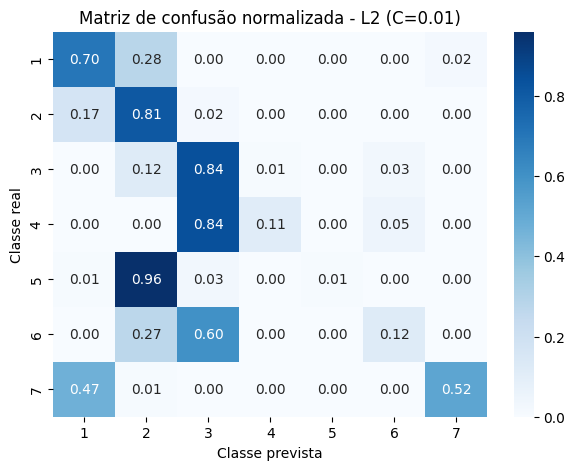

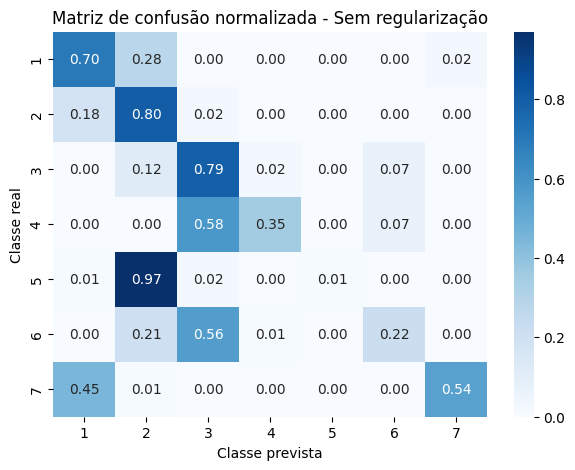

In [32]:
def plot_confusion_matrix_norm(y_true, y_pred, title):
    labels = sorted(y_true.unique())
    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize="true"
    )

    cm_norm = np.round(cm_norm, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

    return pd.DataFrame(cm_norm, index=labels, columns=labels)

cm_l2_norm = plot_confusion_matrix_norm(
    y_test,
    y_pred_l2,
    "Matriz de confusão normalizada - L2 (C=0.01)"
)

cm_sem_reg_norm = plot_confusion_matrix_norm(
    y_test,
    y_pred_sem_reg,
    "Matriz de confusão normalizada - Sem regularização"
)

As matrizes mostram que as classes 1, 2 e 3 foram as melhor classificadas nos dois modelos, com maiores valores na diagonal principal. No modelo com L2, os acertos foram 0,70 para a classe 1, 0,81 para a classe 2 e 0,84 para a classe 3. Sem regularização, esses valores ficaram próximos: 0,70, 0,80 e 0,79, respectivamente.

As maiores confusões ocorreram nas classes minoritárias. A classe 5 foi quase sempre confundida com a classe 2 nos dois modelos, com 0,96 no modelo L2 e 0,97 sem regularização. A classe 6 foi muito confundida com a classe 3, principalmente no modelo L2, com 0,60. A classe 7 foi bastante confundida com a classe 1, com 0,47 no L2 e 0,45 sem regularização.

A retirada da regularização melhorou algumas classes minoritárias. A classe 4 passou de 0,11 para 0,35 de acerto, e a classe 6 passou de 0,12 para 0,22. A classe 7 também teve pequena melhora, de 0,52 para 0,54. Portanto, o modelo sem regularização apresentou melhor equilíbrio entre as classes, embora ainda exista forte confusão nas classes 5 e 6.